In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Notebook is working")


Notebook is working


In [2]:
import pandas as pd

energy = pd.read_csv("energy_germany.csv", skiprows=4)
energy.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,1.496900e+08,1.437600e+08,1.503500e+08,1.569300e+08,1.569300e+08,1.569300e+08,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,9.241070e+09,1.443187e+10,1.550608e+10,2.034558e+10,1.752297e+10,1.943513e+10,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,3.866000e+07,3.947000e+07,3.868000e+07,5.558000e+07,6.572000e+07,7.791000e+07,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.754300e+08,2.332700e+08,4.039900e+08,7.017900e+08,1.254370e+09,1.404060e+09,NaN,NaN,NaN,NaN
4,Angola,AGO,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,7.962000e+07,1.391800e+09,1.149570e+09,2.014260e+09,1.603650e+09,2.902750e+09,NaN,NaN,NaN,NaN


In [3]:
germany_energy = energy[energy["Country Name"] == "Germany"]
germany_energy


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
55,Germany,DEU,"Electricity production from renewable sources,...",EG.ELC.RNWX.KH,NaN,NaN,NaN,NaN,NaN,NaN,...,1.691260e+11,1.961730e+11,2.043820e+11,2.206010e+11,2.327600e+11,2.111432e+11,NaN,NaN,NaN,NaN


In [4]:
# keep only columns that look like years
year_columns = [col for col in germany_energy.columns if col.isdigit()]

germany_energy_years = germany_energy[year_columns]
germany_energy_years.head()


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.698080e+11,1.691260e+11,1.961730e+11,2.043820e+11,2.206010e+11,2.327600e+11,2.111432e+11,NaN,NaN,NaN


In [5]:
germany_energy_clean = germany_energy_years.T.reset_index()
germany_energy_clean.columns = ["year", "energy_kwh_per_capita"]

germany_energy_clean.head()


,year,energy_kwh_per_capita
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


In [6]:
# convert year to number
germany_energy_clean["year"] = germany_energy_clean["year"].astype(int)

# check missing values
germany_energy_clean.isna().sum()


year                      0
energy_kwh_per_capita    33
dtype: int64

In [7]:
germany_energy_clean.head()


,year,energy_kwh_per_capita
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


In [8]:
germany_energy_clean.tail()


,year,energy_kwh_per_capita
60,2020,2.327600e+11
61,2021,2.111432e+11
62,2022,NaN
63,2023,NaN
64,2024,NaN


In [9]:
germany_energy_clean = germany_energy_clean[germany_energy_clean["year"] >= 2000]
germany_energy_clean.head()


,year,energy_kwh_per_capita
40,2000,1.374300e+10
41,2001,1.516200e+10
42,2002,2.135300e+10
43,2003,2.834900e+10
44,2004,3.721100e+10


In [10]:
germany_energy_clean["energy_kwh_per_capita"] = (
    germany_energy_clean["energy_kwh_per_capita"]
    .interpolate(method="linear")
)

germany_energy_clean.isna().sum()


year                     0
energy_kwh_per_capita    0
dtype: int64

In [11]:
germany_energy_clean.to_csv("energy_germany_clean.csv", index=False)


In [12]:
import pandas as pd

temp = pd.read_csv("temperature_raw.csv")
temp.head()


,Entity,Code,Year,temperature_2m
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


In [13]:
temp.columns


Index(['Entity', 'Code', 'Year', 'temperature_2m'], dtype='object')

In [14]:
list(temp.columns)


['Entity', 'Code', 'Year', 'temperature_2m']

In [15]:
# keep only Germany
temp = temp[temp["Entity"] == "Germany"]

# select correct columns
temp = temp[["Year", "temperature_2m"]]

# rename columns
temp.columns = ["year", "avg_temperature"]

temp.head()


,year,avg_temperature
6622,1940,6.586534
6623,1941,7.108514
6624,1942,7.269274
6625,1943,8.899726
6626,1944,8.223510


In [16]:
temp["year"] = temp["year"].astype(int)
temp = temp[temp["year"] >= 2000]

temp["avg_temperature"] = temp["avg_temperature"].interpolate()

temp.isna().sum()


year               0
avg_temperature    0
dtype: int64

In [17]:
temp.to_csv("temperature_germany_clean.csv", index=False)


In [18]:
co2 = pd.read_csv("co2_raw.csv")
list(co2.columns)


['Entity', 'Code', 'Year', 'emissions_total_per_capita']

In [19]:
list(co2.columns)


['Entity', 'Code', 'Year', 'emissions_total_per_capita']

In [20]:
# keep only Germany
co2 = co2[co2["Entity"] == "Germany"]

# select correct columns
co2 = co2[["Year", "emissions_total_per_capita"]]

# rename columns
co2.columns = ["year", "co2_per_capita"]

# clean year and filter range
co2["year"] = co2["year"].astype(int)
co2 = co2[co2["year"] >= 2000]

# handle missing values
co2["co2_per_capita"] = co2["co2_per_capita"].interpolate()

# sanity check
co2.isna().sum()


year              0
co2_per_capita    0
dtype: int64

In [21]:
co2.to_csv("co2_germany_clean.csv", index=False)


In [22]:
gdp = pd.read_csv("gdp_raw.csv", skiprows=4)
gdp.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,27587.249804,28548.890432,29419.208623,29699.180537,22729.889759,26292.917936,29195.267023,31430.935368,33373.917459,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1186.349620,1160.458789,1219.356473,1253.445317,1275.886801,1304.275651,...,1490.907546,1490.911098,1489.942137,1479.372387,1399.398498,1425.209057,1440.430366,1431.721790,1435.356278,NaN
2,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,563.872337,562.769574,553.125152,557.861533,527.834554,408.625855,377.665627,378.066303,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1130.411973,1127.572551,1144.920732,1199.197534,1236.216308,1258.758091,...,1815.171203,1808.722201,1814.694636,1829.068064,1719.261504,1721.909475,1757.456590,1778.864347,1816.346044,NaN
4,Angola,AGO,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3454.033172,3328.898212,3196.790070,3083.975344,2864.161460,2832.817771,2860.902519,2809.157280,2845.477793,NaN


In [23]:
# keep Germany only
gdp = gdp[gdp["Country Name"] == "Germany"]

# keep year columns only
year_cols = [col for col in gdp.columns if col.isdigit()]
gdp = gdp[year_cols]

# reshape
gdp = gdp.T.reset_index()
gdp.columns = ["year", "gdp_per_capita"]

gdp.head()


,year,gdp_per_capita
0,1960,12606.944265
1,1961,13048.007834
2,1962,13531.751366
3,1963,13773.764821
4,1964,14570.483336


In [24]:
gdp["year"] = gdp["year"].astype(int)
gdp = gdp[gdp["year"] >= 2000]

gdp["gdp_per_capita"] = gdp["gdp_per_capita"].interpolate()

gdp.isna().sum()


year              0
gdp_per_capita    0
dtype: int64

In [25]:
gdp.to_csv("gdp_germany_clean.csv", index=False)


In [26]:
import pandas as pd

energy = pd.read_csv("energy_germany_clean.csv")
temp = pd.read_csv("temperature_germany_clean.csv")
co2 = pd.read_csv("co2_germany_clean.csv")
gdp = pd.read_csv("gdp_germany_clean.csv")


In [27]:
df = energy.merge(temp, on="year", how="inner")
df = df.merge(co2, on="year", how="inner")
df = df.merge(gdp, on="year", how="inner")

df.head()


,year,energy_kwh_per_capita,avg_temperature,co2_per_capita,gdp_per_capita
0,2000,1.374300e+10,9.902544,10.990293,35104.130847
1,2001,1.516200e+10,9.038270,11.170651,35618.514370
2,2002,2.135300e+10,9.605247,10.952268,35477.515154
3,2003,2.834900e+10,9.481328,10.893722,35270.022728
4,2004,3.721100e+10,9.054963,10.677804,35687.637871


In [28]:
df.shape


(25, 5)

In [29]:
df.isna().sum()


year                     0
energy_kwh_per_capita    0
avg_temperature          0
co2_per_capita           0
gdp_per_capita           0
dtype: int64

In [30]:
df.describe()

,year,energy_kwh_per_capita,avg_temperature,co2_per_capita,gdp_per_capita
count,25.000000,2.500000e+01,25.000000,25.000000,25.000000
mean,2012.000000,1.221037e+11,9.753645,9.643181,40139.386658
std,7.359801,7.641968e+10,0.696812,1.274703,3424.605045
min,2000.000000,1.374300e+10,8.006869,6.768824,35104.130847
25%,2006.000000,5.248000e+10,9.241366,9.101415,36940.407867
50%,2012.000000,1.212870e+11,9.698983,9.950070,40834.508822
75%,2018.000000,2.043820e+11,10.416997,10.577880,43543.480705
max,2024.000000,2.327600e+11,10.952907,11.170651,44817.131633


In [31]:
df.corr()


,year,energy_kwh_per_capita,avg_temperature,co2_per_capita,gdp_per_capita
year,1.000000,0.979480,0.567199,-0.929960,0.967268
energy_kwh_per_capita,0.979480,1.000000,0.585520,-0.886526,0.972105
avg_temperature,0.567199,0.585520,1.000000,-0.644973,0.572282
co2_per_capita,-0.929960,-0.886526,-0.644973,1.000000,-0.837670
gdp_per_capita,0.967268,0.972105,0.572282,-0.837670,1.000000


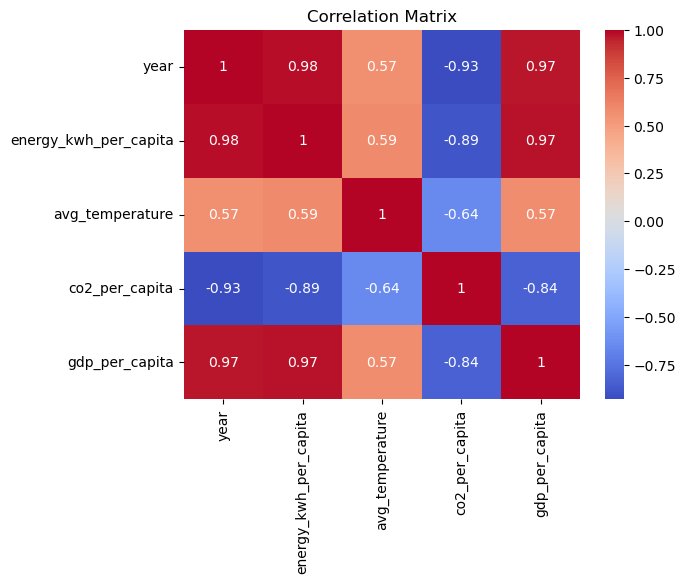

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [33]:
import statsmodels.api as sm

X = df["avg_temperature"]
y = df["energy_kwh_per_capita"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     energy_kwh_per_capita   R-squared:                       0.343
Model:                               OLS   Adj. R-squared:                  0.314
Method:                    Least Squares   F-statistic:                     12.00
Date:                   Sat, 31 Jan 2026   Prob (F-statistic):            0.00211
Time:                           14:10:20   Log-Likelihood:                -656.20
No. Observations:                     25   AIC:                             1316.
Df Residuals:                         23   BIC:                             1319.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -5.042e+11   1.81e+11     -2.782      0.011   -8.79e+11   -1.29e+11
avg_temperature  6.421e+10   1.85e+10      3.464      0.002    2.59e+10    1.03e+11
==============================================================================
Omnibus:                        1.340   Durbin-Watson:                   0.612
Prob(Omnibus):                  0.512   Jarque-Bera (JB):                0.909
Skew:                          -0.056   Prob(JB):                        0.635
Kurtosis:                       2.073   Cond. No.                         141.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
import statsmodels.api as sm

X = df[["avg_temperature", "co2_per_capita", "gdp_per_capita"]]
y = df["energy_kwh_per_capita"]

X = sm.add_constant(X)
multi_model = sm.OLS(y, X).fit()

multi_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     energy_kwh_per_capita   R-squared:                       0.963
Model:                               OLS   Adj. R-squared:                  0.957
Method:                    Least Squares   F-statistic:                     180.6
Date:                   Sat, 31 Jan 2026   Prob (F-statistic):           3.77e-15
Time:                           14:10:20   Log-Likelihood:                -620.35
No. Observations:                     25   AIC:                             1249.
Df Residuals:                         21   BIC:                             1254.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -4.027e+11   1.31e+11     -3.082      0.006   -6.74e+11   -1.31e+11
avg_temperature -2.057e+09   6.07e+09     -0.339      0.738   -1.47e+10    1.06e+10
co2_per_capita  -1.514e+10   4.98e+09     -3.040      0.006   -2.55e+10   -4.78e+09
gdp_per_capita   1.721e+07   1.73e+06      9.963      0.000    1.36e+07    2.08e+07
==============================================================================
Omnibus:                        7.895   Durbin-Watson:                   1.155
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                5.983
Skew:                           0.896   Prob(JB):                       0.0502
Kurtosis:                       4.591   Cond. No.                     1.67e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.67e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data


,feature,VIF
0,const,1714.104946
1,avg_temperature,1.722428
2,co2_per_capita,3.882966
3,gdp_per_capita,3.372062


In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data


,feature,VIF
0,const,1714.104946
1,avg_temperature,1.722428
2,co2_per_capita,3.882966
3,gdp_per_capita,3.372062


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif


,Feature,VIF
0,const,1714.104946
1,avg_temperature,1.722428
2,co2_per_capita,3.882966
3,gdp_per_capita,3.372062
